# 01 — Le simulateur de flipper

Dans ce notebook : construire la table, comprendre ses paramètres, regarder
la physique tourner, et jouer manuellement pour vérifier que le flipper est
agréable. **Aucun apprentissage ici** — d'abord, un monde qui fonctionne.

Exécution locale : lancer Jupyter depuis la **racine du repo**, avec le
noyau du venv du projet (`.venv`) — voir le README pour la mise en place.

In [1]:
import matplotlib.pyplot as plt
from pinball.config import BoardConfig
from pinball.env import PinballEnv
from pinball.render import render_debug

## La table est une configuration

Tout le plateau est décrit par une dataclass. Changer la table = changer des
nombres. Regardons la table par défaut, puis une variante.

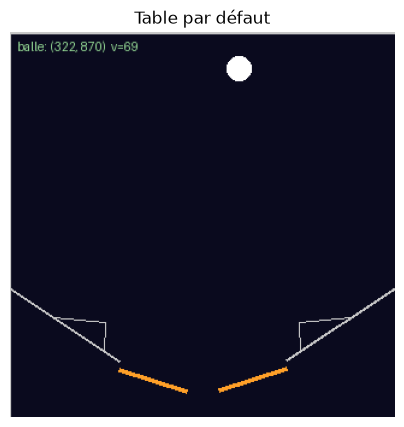

In [2]:
cfg = BoardConfig()
env = PinballEnv(cfg, seed=0)
env.reset()
plt.figure(figsize=(5, 5)); plt.imshow(render_debug(env.sim)); plt.axis("off")
plt.title("Table par défaut"); plt.show()

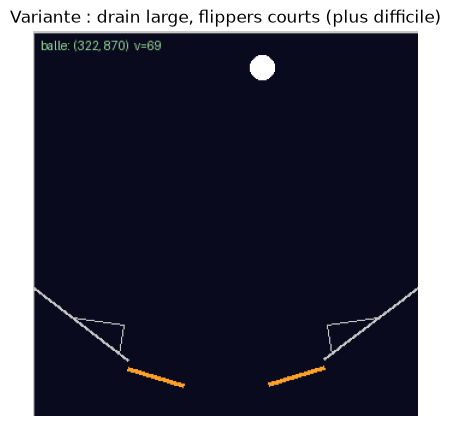

In [3]:
large = BoardConfig(drain_gap=120.0, flipper_length=90.0)
env2 = PinballEnv(large, seed=0)
env2.reset()
plt.figure(figsize=(5, 5)); plt.imshow(render_debug(env2.sim)); plt.axis("off")
plt.title("Variante : drain large, flippers courts (plus difficile)"); plt.show()

## Ce que voit le modèle : 64×64, 2 frames

L'observation est volontairement pauvre : une petite image en niveaux de
gris. Pourquoi DEUX frames ? Une image seule ne contient pas la vitesse de
la balle — deux images identiques peuvent cacher une balle montante ou
descendante. Avec deux frames, le mouvement est visible : l'état redevient
(approximativement) Markovien.

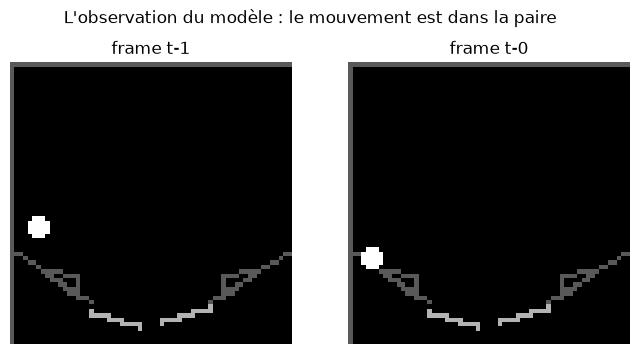

In [4]:
obs = env.reset(seed=3)
for _ in range(12):
    obs, info = env.step(0)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for i, ax in enumerate(axes):
    ax.imshow(obs[i], cmap="gray"); ax.set_title(f"frame t-{1-i}"); ax.axis("off")
plt.suptitle("L'observation du modèle : le mouvement est dans la paire"); plt.show()

## Une partie en vidéo (politique : ne rien faire)

In [5]:
def episode_gif(env, policy, path, seed=None, max_steps=450):
    """Joue un épisode et l'enregistre en GIF (rendu debug)."""
    env.reset(seed=seed)
    frames = [render_debug(env.sim)]
    for _ in range(max_steps):
        _, info = env.step(policy())
        frames.append(render_debug(env.sim))
        if info["done"]:
            break
    frames[0].save(path, save_all=True, append_images=frames[1:],
                   duration=66, loop=0)
    return info

info = episode_gif(PinballEnv(seed=5), lambda: 0, "episode_passif.gif", seed=5)
print(f"Épisode terminé en {info['steps']} pas ({info['steps']/15:.1f} s), "
      f"balle perdue : {info['ball_lost']}")

Épisode terminé en 355 pas (23.7 s), balle perdue : False


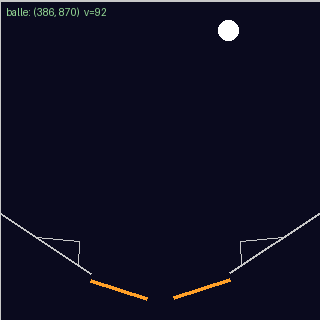

In [8]:
from IPython.display import Image as IPImage, display
display(IPImage("episode_passif.gif"))

## Jouer à la main (widgets)

Deux cases à cocher = les deux boutons du flipper. Le bouton « Avancer 1 s »
fait 15 pas de contrôle. Vérifie que : la balle rebondit, les flippers
frappent fort, les slingshots relancent, et que la balle finit au drain.

In [ ]:
import ipywidgets as widgets

env_manual = PinballEnv(seed=None)
env_manual.reset()
left_box = widgets.Checkbox(description="Flipper gauche")
right_box = widgets.Checkbox(description="Flipper droit")
out = widgets.Output()

def advance(_):
    with out:
        out.clear_output(wait=True)
        action = int(left_box.value) | (int(right_box.value) << 1)
        for _ in range(15):
            _, info = env_manual.step(action)
            if info["done"]:
                break
        plt.figure(figsize=(5, 5)); plt.imshow(render_debug(env_manual.sim))
        plt.axis("off"); plt.show()
        if info["done"]:
            print("Balle perdue ! Relance...")
            env_manual.reset()

button = widgets.Button(description="Avancer 1 s")
button.on_click(advance)
display(widgets.HBox([left_box, right_box, button]), out)
advance(None)

Output()

## À retenir

- La table est **paramétrable** (`BoardConfig`) : gravité, flippers, drain...
- La physique est **réelle** (pymunk) : la balle est frappée, pas téléportée.
- Le modèle ne verra QUE l'image 64×64×2 — jamais les positions exactes.

Prochaine étape (notebook 02) : générer le dataset d'expérience en laissant
une politique aléatoire jouer des milliers de parties, toute seule.